# 07a. Frequency-Domain Features & Correlation Analysis

## Objective

This notebook extracts frequency-domain wearable features from the preprocessed Parkinson's Disease Smartwatch Dataset (PADS) signals, reshapes the extracted features to **one row per participant**, and identifies strongly correlated wearable features.

Following the decision established in Notebook 04, each post-trim recording is first interpolated onto a **uniform 100 Hz grid** before FFT-based feature extraction. The interpolation preserves the established post-trim recording lengths of **976** and **2,000 samples**.

The notebook produces:

- a recording-level frequency-domain feature table for quality assurance;
- a **participant-level wide feature table** with one row per `patient_id`;
- task- and wrist-specific feature columns such as `CrossArms_LeftWrist_acc_x_dominant_frequency`;
- a Pearson correlation matrix calculated from the participant-level feature table;
- a summary of strongly correlated wearable features; and
- validation confirming that uniform resampling preserves the post-trim sample lengths.


## Frequency-Domain Features

For each accelerometer and gyroscope axis and magnitude signal, the following features are extracted:

- **Dominant frequency**
- **Spectral centroid**
- **Spectral entropy**
- **Spectral power**

The analysis includes accelerometer X, Y, Z, and magnitude, together with gyroscope X, Y, Z, and magnitude. This produces **32 frequency-domain features per recording**.


## Uniform 100 Hz Resampling

Notebook 04 found timestamp jitter in the raw smartwatch recordings and concluded that FFT-based features should be calculated only after interpolation onto a uniform 100 Hz grid.

The feature module therefore:

1. reads the post-trim preprocessed recordings;
2. replaces irregular timestamps with exact 0.01-second spacing;
3. linearly interpolates all accelerometer, gyroscope, and magnitude channels;
4. preserves the existing number of samples; and
5. performs the FFT using a fixed sampling frequency of 100 Hz.

The original timestamp-based sampling frequency is retained only as a quality-assurance field. It is not used for the FFT.


In [1]:
# Libraries and project paths
# =============================================================================

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

cwd = Path.cwd()

if (cwd / "data").exists() and (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists() and (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing data/ and src/."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.frequency_features import (
    TARGET_SAMPLING_FREQUENCY,
    build_correlation_summary,
    build_frequency_feature_table,
    compute_feature_correlations,
    get_accelerometer_feature_columns,
    get_frequency_feature_columns,
    get_gyroscope_feature_columns,
    summarize_strong_correlations,
)

NPZ_DIR = PROJECT_ROOT / "data" / "processed" / "preprocessed_signals"

# Final participant-level frequency-domain feature table.
# This is the file intended for downstream integration/modeling.
FEATURE_OUTPUT = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "frequency_domain_features.csv"
)

# Optional recording-level table retained for QA and traceability.
RECORDING_FEATURE_OUTPUT = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "frequency_domain_features_recording_level.csv"
)

CORRELATION_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "correlation_analysis"
)

CORRELATION_MATRIX_OUTPUT = (
    CORRELATION_OUTPUT_DIR
    / "frequency_feature_correlation_matrix.csv"
)

STRONG_CORRELATIONS_OUTPUT = (
    CORRELATION_OUTPUT_DIR
    / "strongly_correlated_features.csv"
)

CORRELATION_SUMMARY_OUTPUT = (
    CORRELATION_OUTPUT_DIR
    / "correlation_analysis_summary.csv"
)

RESAMPLING_LENGTH_OUTPUT = (
    CORRELATION_OUTPUT_DIR
    / "post_resampling_length_summary.csv"
)

STRONG_CORRELATION_THRESHOLD = 0.80
EXPECTED_POST_TRIM_LENGTHS = {976, 2000}

print("Project root:", PROJECT_ROOT)
print("Processed signal directory:", NPZ_DIR)
print("Target sampling frequency:", TARGET_SAMPLING_FREQUENCY, "Hz")


Project root: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease
Processed signal directory: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\preprocessed_signals
Target sampling frequency: 100.0 Hz


## 1. Confirm Input Availability

In [2]:
if not NPZ_DIR.exists():
    raise FileNotFoundError(
        f"Could not locate {NPZ_DIR}. "
        "Run or obtain the signal-preprocessing outputs first."
    )

npz_files = sorted(NPZ_DIR.glob("*_preprocessed.npz"))

if not npz_files:
    raise FileNotFoundError(
        f"No participant .npz files were found in {NPZ_DIR}."
    )

print("Participant NPZ files found:", len(npz_files))
print("First file:", npz_files[0].name)

assert len(npz_files) == 469, (
    f"Expected 469 participant files, found {len(npz_files)}."
)


Participant NPZ files found: 469
First file: 001_preprocessed.npz


## 2. Inspect the Preprocessed Signal Structure

In [3]:
with np.load(npz_files[0], allow_pickle=False) as sample:
    sample_columns = sample["__columns__"].astype(str).tolist()
    sample_recording_keys = (
        sample["__recording_keys__"].astype(str).tolist()
    )
    first_recording_key = sample_recording_keys[0]
    first_recording_shape = sample[first_recording_key].shape

print("Signal columns:", sample_columns)
print("Recordings in sample participant:", len(sample_recording_keys))
print("First recording key:", first_recording_key)
print("First recording shape:", first_recording_shape)

expected_columns = [
    "Time",
    "Accelerometer_X",
    "Accelerometer_Y",
    "Accelerometer_Z",
    "Gyroscope_X",
    "Gyroscope_Y",
    "Gyroscope_Z",
    "Acc_Magnitude",
    "Gyro_Magnitude",
]

missing_columns = [
    column
    for column in expected_columns
    if column not in sample_columns
]

assert not missing_columns
assert len(sample_recording_keys) == 22


Signal columns: ['Time', 'Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z', 'Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z', 'Acc_Magnitude', 'Gyro_Magnitude']
Recordings in sample participant: 22
First recording key: CrossArms__LeftWrist
First recording shape: (976, 9)


## 3. Extract Frequency-Domain Features After 100 Hz Resampling

In [4]:
frequency_features = build_frequency_feature_table(NPZ_DIR)

print("Frequency feature table shape:", frequency_features.shape)
print("Participants:", frequency_features["patient_id"].nunique())
print("Recordings:", len(frequency_features))
print("Tasks:", frequency_features["task"].nunique())
print("Wrists:", frequency_features["wrist"].nunique())

assert frequency_features["patient_id"].nunique() == 469
assert len(frequency_features) == 10_318

frequency_features.head()


Frequency feature table shape: (10318, 42)
Participants: 469
Recordings: 10318
Tasks: 11
Wrists: 2


,patient_id,recording_key,task,wrist,n_samples,original_sampling_frequency_hz,sampling_frequency_hz,resampled_n_samples,uniform_time_start_s,uniform_time_end_s,acc_x_dominant_frequency,acc_x_spectral_centroid,acc_x_spectral_entropy,acc_x_spectral_power,acc_y_dominant_frequency,acc_y_spectral_centroid,acc_y_spectral_entropy,acc_y_spectral_power,acc_z_dominant_frequency,acc_z_spectral_centroid,acc_z_spectral_entropy,acc_z_spectral_power,acc_magnitude_dominant_frequency,acc_magnitude_spectral_centroid,acc_magnitude_spectral_entropy,acc_magnitude_spectral_power,gyro_x_dominant_frequency,gyro_x_spectral_centroid,gyro_x_spectral_entropy,gyro_x_spectral_power,gyro_y_dominant_frequency,gyro_y_spectral_centroid,gyro_y_spectral_entropy,gyro_y_spectral_power,gyro_z_dominant_frequency,gyro_z_spectral_centroid,gyro_z_spectral_entropy,gyro_z_spectral_power,gyro_magnitude_dominant_frequency,gyro_magnitude_spectral_centroid,gyro_magnitude_spectral_entropy,gyro_magnitude_spectral_power
0,001,CrossArms__LeftWrist,CrossArms,LeftWrist,976,100.031100,100.0,976,0.0,9.75,0.819672,1.866823,0.526448,0.001782,1.229508,2.363701,0.557386,0.005342,0.922131,2.112073,0.540519,0.002527,0.102459,0.570117,0.234482,0.007209,0.204918,2.155251,0.597538,0.077220,0.307377,0.625410,0.400327,0.202952,0.409836,0.530284,0.372805,0.978077,0.102459,0.354928,0.292612,1.152311
1,001,CrossArms__RightWrist,CrossArms,RightWrist,976,99.344008,100.0,976,0.0,9.75,0.819672,1.663690,0.513621,0.001953,1.331967,2.608833,0.569853,0.004633,0.922131,2.334017,0.570797,0.002340,0.102459,0.719561,0.270446,0.006181,0.409836,0.997054,0.439185,0.240653,0.307377,0.528197,0.380307,0.271797,0.409836,0.538821,0.370770,0.829611,0.102459,0.365697,0.306318,1.201251
2,001,DrinkGlas__LeftWrist,DrinkGlas,LeftWrist,976,100.038257,100.0,976,0.0,9.75,0.614754,3.138822,0.640340,0.006228,7.889344,6.107938,0.759575,0.021786,0.922131,4.049227,0.680939,0.008750,0.204918,3.759089,0.683259,0.022893,0.307377,2.467019,0.619202,1.529727,0.204918,1.045782,0.457844,0.390406,0.102459,0.883988,0.442721,0.334447,0.102459,2.527846,0.629801,1.268809
3,001,DrinkGlas__RightWrist,DrinkGlas,RightWrist,976,99.353420,100.0,976,0.0,9.75,2.049180,3.303895,0.622688,0.017004,1.331967,5.656435,0.744571,0.014850,1.639344,3.113583,0.630309,0.018572,0.204918,2.382510,0.583509,0.025706,1.024590,2.503980,0.598465,1.204848,1.844262,2.019669,0.562906,1.187956,0.102459,1.570955,0.537322,0.564632,0.102459,1.353934,0.522233,1.754532
4,001,Entrainment__LeftWrist,Entrainment,LeftWrist,2000,100.054962,100.0,2000,0.0,19.99,4.150000,4.777742,0.693084,0.000474,2.000000,3.313669,0.634358,0.000400,2.050000,2.472761,0.426827,0.001618,0.100000,3.196574,0.633715,0.000574,2.450000,5.570762,0.731797,0.002152,2.050000,2.708283,0.499449,0.004224,2.150000,2.372372,0.616565,0.002656,0.100000,3.230800,0.664859,0.002213


## 4. Validate Uniform 100 Hz Resampling

These checks confirm that:

- every recording was analyzed at exactly 100 Hz;
- the resampled sample count equals the original post-trim sample count;
- the only retained lengths are 976 and 2,000 samples; and
- the uniform grid starts at 0 seconds and has the expected end time.


In [5]:
required_resampling_columns = [
    "n_samples",
    "original_sampling_frequency_hz",
    "sampling_frequency_hz",
    "resampled_n_samples",
    "uniform_time_start_s",
    "uniform_time_end_s",
]

missing_resampling_columns = [
    column
    for column in required_resampling_columns
    if column not in frequency_features.columns
]

print("Missing validation columns:", missing_resampling_columns)
assert not missing_resampling_columns

assert np.allclose(
    frequency_features["sampling_frequency_hz"],
    TARGET_SAMPLING_FREQUENCY,
)


Missing validation columns: []


In [6]:
lengths_preserved = (
    frequency_features["n_samples"]
    == frequency_features["resampled_n_samples"]
)

print("Recordings with preserved length:", int(lengths_preserved.sum()))
print("Recordings with changed length:", int((~lengths_preserved).sum()))

assert lengths_preserved.all()


Recordings with preserved length: 10318
Recordings with changed length: 0


In [7]:
post_resampling_length_summary = (
    frequency_features["resampled_n_samples"]
    .value_counts()
    .sort_index()
    .rename_axis("post_trim_samples")
    .reset_index(name="recordings")
)

observed_lengths = set(
    post_resampling_length_summary["post_trim_samples"]
    .astype(int)
    .tolist()
)

print("Observed post-resampling lengths:", sorted(observed_lengths))
print("Expected post-trim lengths:", sorted(EXPECTED_POST_TRIM_LENGTHS))

assert observed_lengths == EXPECTED_POST_TRIM_LENGTHS

post_resampling_length_summary


Observed post-resampling lengths: [976, 2000]
Expected post-trim lengths: [976, 2000]


,post_trim_samples,recordings
0,976,7504
1,2000,2814


In [8]:
expected_end_time = (
    frequency_features["resampled_n_samples"] - 1
) / TARGET_SAMPLING_FREQUENCY

valid_uniform_grid = (
    np.isclose(
        frequency_features["uniform_time_start_s"],
        0.0,
    )
    & np.isclose(
        frequency_features["uniform_time_end_s"],
        expected_end_time,
    )
)

print("Recordings with valid 100 Hz grid:", int(valid_uniform_grid.sum()))
print("Recordings with invalid grid:", int((~valid_uniform_grid).sum()))

assert valid_uniform_grid.all()

print(
    "Confirmed: all recordings were resampled onto a uniform "
    "100 Hz grid and retained lengths of 976 or 2,000 samples."
)


Recordings with valid 100 Hz grid: 10318
Recordings with invalid grid: 0
Confirmed: all recordings were resampled onto a uniform 100 Hz grid and retained lengths of 976 or 2,000 samples.


## 5. Original Sampling-Frequency QA

The original timestamp-based sampling frequency is included only for quality-assurance reporting. The FFT uses the uniformly resampled 100 Hz signals.


In [9]:
original_sampling_qa = (
    frequency_features["original_sampling_frequency_hz"]
    .describe()
    .to_frame(name="value")
)

original_sampling_qa


,value
count,10318.000000
mean,99.767056
std,0.436842
min,99.188951
25%,99.344008
50%,99.954818
75%,100.054961
max,100.814921


## 6. Accelerometer and Gyroscope Feature Groups

In [10]:
all_frequency_columns = get_frequency_feature_columns(frequency_features)

accelerometer_frequency_columns = (
    get_accelerometer_feature_columns(frequency_features)
)

gyroscope_frequency_columns = (
    get_gyroscope_feature_columns(frequency_features)
)

feature_group_summary = pd.DataFrame(
    {
        "feature_group": [
            "Accelerometer",
            "Gyroscope",
            "Total",
        ],
        "number_of_features": [
            len(accelerometer_frequency_columns),
            len(gyroscope_frequency_columns),
            len(all_frequency_columns),
        ],
    }
)

assert len(accelerometer_frequency_columns) == 16
assert len(gyroscope_frequency_columns) == 16
assert len(all_frequency_columns) == 32

feature_group_summary


,feature_group,number_of_features
0,Accelerometer,16
1,Gyroscope,16
2,Total,32


## 7. Frequency-Feature Quality Assurance

In [11]:
identifier_columns = ["patient_id", "task", "wrist"]

duplicate_recordings = frequency_features.duplicated(
    subset=identifier_columns,
    keep=False,
)

feature_qa = pd.DataFrame(
    {
        "metric": [
            "Rows",
            "Unique participant-task-wrist records",
            "Duplicate participant-task-wrist records",
            "Frequency features",
            "Missing frequency-feature values",
            "Infinite frequency-feature values",
            "Recordings resampled at 100 Hz",
            "Recordings retaining post-trim length",
        ],
        "value": [
            len(frequency_features),
            frequency_features[identifier_columns]
            .drop_duplicates()
            .shape[0],
            int(duplicate_recordings.sum()),
            len(all_frequency_columns),
            int(
                frequency_features[all_frequency_columns]
                .isna()
                .sum()
                .sum()
            ),
            int(
                np.isinf(
                    frequency_features[all_frequency_columns]
                    .to_numpy(dtype=float)
                ).sum()
            ),
            int(
                np.isclose(
                    frequency_features["sampling_frequency_hz"],
                    TARGET_SAMPLING_FREQUENCY,
                ).sum()
            ),
            int(lengths_preserved.sum()),
        ],
    }
)

feature_qa


,metric,value
0,Rows,10318
1,Unique participant-task-wrist records,10318
2,Duplicate participant-task-wrist records,0
3,Frequency features,32
4,Missing frequency-feature values,0
5,Infinite frequency-feature values,0
6,Recordings resampled at 100 Hz,10318
7,Recordings retaining post-trim length,10318


## 8. Reshape Frequency Features to One Row per Participant

The extracted table above is recording-level, with one row for each participant-task-wrist combination. For downstream integration and modeling, the frequency-domain features are reshaped to a **participant-level wide format**.

Each frequency feature is renamed using the pattern:

`Task_Wrist_Feature`

For example:

- `CrossArms_LeftWrist_acc_x_dominant_frequency`
- `CrossArms_RightWrist_acc_x_spectral_entropy`
- `FingerTap_LeftWrist_gyro_magnitude_spectral_power`

After reshaping, each `patient_id` appears exactly once.

In [12]:
# Frequency-domain feature columns only.
recording_frequency_columns = get_frequency_feature_columns(
    frequency_features
)

# Confirm that each participant-task-wrist combination is unique
# before pivoting.
duplicate_keys = frequency_features.duplicated(
    subset=["patient_id", "task", "wrist"],
    keep=False,
)

assert not duplicate_keys.any(), (
    "Duplicate patient/task/wrist combinations were found. "
    "Resolve duplicates before creating the participant-level table."
)

# Create a stable task/wrist prefix for every recording.
wide_source = frequency_features[
    ["patient_id", "task", "wrist"] + recording_frequency_columns
].copy()

wide_source["feature_prefix"] = (
    wide_source["task"].astype(str)
    + "_"
    + wide_source["wrist"].astype(str)
)

# Convert the 32 recording-level features into task/wrist-specific
# participant-level columns.
frequency_features_wide = (
    wide_source
    .set_index(["patient_id", "feature_prefix"])[recording_frequency_columns]
    .stack()
    .rename("value")
    .reset_index()
)

frequency_features_wide["feature_name"] = (
    frequency_features_wide["feature_prefix"]
    + "_"
    + frequency_features_wide["level_2"]
)

frequency_features_wide = (
    frequency_features_wide
    .pivot(
        index="patient_id",
        columns="feature_name",
        values="value",
    )
    .reset_index()
)

frequency_features_wide.columns.name = None

# Keep patient identifiers as zero-padded strings.
frequency_features_wide["patient_id"] = (
    frequency_features_wide["patient_id"]
    .astype(str)
    .str.zfill(3)
)

# Validate participant-level structure.
assert frequency_features_wide["patient_id"].is_unique
assert frequency_features_wide["patient_id"].nunique() == 469
assert len(frequency_features_wide) == 469

participant_frequency_columns = [
    column
    for column in frequency_features_wide.columns
    if column != "patient_id"
]

print(
    "Participant-level frequency feature table shape:",
    frequency_features_wide.shape,
)
print(
    "Unique participants:",
    frequency_features_wide["patient_id"].nunique(),
)
print(
    "Participant-level feature columns:",
    len(participant_frequency_columns),
)

frequency_features_wide.head()

Participant-level frequency feature table shape: (469, 705)
Unique participants: 469
Participant-level feature columns: 704


,patient_id,CrossArms_LeftWrist_acc_magnitude_dominant_frequency,CrossArms_LeftWrist_acc_magnitude_spectral_centroid,CrossArms_LeftWrist_acc_magnitude_spectral_entropy,CrossArms_LeftWrist_acc_magnitude_spectral_power,CrossArms_LeftWrist_acc_x_dominant_frequency,CrossArms_LeftWrist_acc_x_spectral_centroid,CrossArms_LeftWrist_acc_x_spectral_entropy,CrossArms_LeftWrist_acc_x_spectral_power,CrossArms_LeftWrist_acc_y_dominant_frequency,CrossArms_LeftWrist_acc_y_spectral_centroid,CrossArms_LeftWrist_acc_y_spectral_entropy,CrossArms_LeftWrist_acc_y_spectral_power,CrossArms_LeftWrist_acc_z_dominant_frequency,CrossArms_LeftWrist_acc_z_spectral_centroid,CrossArms_LeftWrist_acc_z_spectral_entropy,CrossArms_LeftWrist_acc_z_spectral_power,CrossArms_LeftWrist_gyro_magnitude_dominant_frequency,CrossArms_LeftWrist_gyro_magnitude_spectral_centroid,CrossArms_LeftWrist_gyro_magnitude_spectral_entropy,CrossArms_LeftWrist_gyro_magnitude_spectral_power,CrossArms_LeftWrist_gyro_x_dominant_frequency,CrossArms_LeftWrist_gyro_x_spectral_centroid,CrossArms_LeftWrist_gyro_x_spectral_entropy,CrossArms_LeftWrist_gyro_x_spectral_power,CrossArms_LeftWrist_gyro_y_dominant_frequency,CrossArms_LeftWrist_gyro_y_spectral_centroid,CrossArms_LeftWrist_gyro_y_spectral_entropy,CrossArms_LeftWrist_gyro_y_spectral_power,CrossArms_LeftWrist_gyro_z_dominant_frequency,CrossArms_LeftWrist_gyro_z_spectral_centroid,CrossArms_LeftWrist_gyro_z_spectral_entropy,CrossArms_LeftWrist_gyro_z_spectral_power,CrossArms_RightWrist_acc_magnitude_dominant_frequency,CrossArms_RightWrist_acc_magnitude_spectral_centroid,CrossArms_RightWrist_acc_magnitude_spectral_entropy,CrossArms_RightWrist_acc_magnitude_spectral_power,CrossArms_RightWrist_acc_x_dominant_frequency,CrossArms_RightWrist_acc_x_spectral_centroid,CrossArms_RightWrist_acc_x_spectral_entropy,CrossArms_RightWrist_acc_x_spectral_power,CrossArms_RightWrist_acc_y_dominant_frequency,CrossArms_RightWrist_acc_y_spectral_centroid,CrossArms_RightWrist_acc_y_spectral_entropy,CrossArms_RightWrist_acc_y_spectral_power,CrossArms_RightWrist_acc_z_dominant_frequency,CrossArms_RightWrist_acc_z_spectral_centroid,CrossArms_RightWrist_acc_z_spectral_entropy,CrossArms_RightWrist_acc_z_spectral_power,CrossArms_RightWrist_gyro_magnitude_dominant_frequency,CrossArms_RightWrist_gyro_magnitude_spectral_centroid,CrossArms_RightWrist_gyro_magnitude_spectral_entropy,CrossArms_RightWrist_gyro_magnitude_spectral_power,CrossArms_RightWrist_gyro_x_dominant_frequency,CrossArms_RightWrist_gyro_x_spectral_centroid,CrossArms_RightWrist_gyro_x_spectral_entropy,CrossArms_RightWrist_gyro_x_spectral_power,CrossArms_RightWrist_gyro_y_dominant_frequency,CrossArms_RightWrist_gyro_y_spectral_centroid,CrossArms_RightWrist_gyro_y_spectral_entropy,CrossArms_RightWrist_gyro_y_spectral_power,CrossArms_RightWrist_gyro_z_dominant_frequency,CrossArms_RightWrist_gyro_z_spectral_centroid,CrossArms_RightWrist_gyro_z_spectral_entropy,CrossArms_RightWrist_gyro_z_spectral_power,DrinkGlas_LeftWrist_acc_magnitude_dominant_frequency,DrinkGlas_LeftWrist_acc_magnitude_spectral_centroid,DrinkGlas_LeftWrist_acc_magnitude_spectral_entropy,DrinkGlas_LeftWrist_acc_magnitude_spectral_power,DrinkGlas_LeftWrist_acc_x_dominant_frequency,DrinkGlas_LeftWrist_acc_x_spectral_centroid,DrinkGlas_LeftWrist_acc_x_spectral_entropy,DrinkGlas_LeftWrist_acc_x_spectral_power,DrinkGlas_LeftWrist_acc_y_dominant_frequency,DrinkGlas_LeftWrist_acc_y_spectral_centroid,DrinkGlas_LeftWrist_acc_y_spectral_entropy,DrinkGlas_LeftWrist_acc_y_spectral_power,DrinkGlas_LeftWrist_acc_z_dominant_frequency,DrinkGlas_LeftWrist_acc_z_spectral_centroid,DrinkGlas_LeftWrist_acc_z_spectral_entropy,DrinkGlas_LeftWrist_acc_z_spectral_power,DrinkGlas_LeftWrist_gyro_magnitude_dominant_frequency,DrinkGlas_LeftWrist_gyro_magnitude_spectral_centroid,DrinkGlas_LeftWrist_gyro_magnitude_spectral_entropy,DrinkGlas_LeftWrist_gyro_magnitude_spectral_power,DrinkGlas_LeftWrist_gyro_x_dominant_frequency,DrinkGlas_LeftWrist_gyro_x_spectral_centroid,Drin

## 9. Save the Frequency-Domain Feature Tables

In [13]:
FEATURE_OUTPUT.parent.mkdir(
    parents=True,
    exist_ok=True,
)

# Retain recording-level features for QA/traceability.
frequency_features.to_csv(
    RECORDING_FEATURE_OUTPUT,
    index=False,
)

# Save the participant-level wide table as the main feature output.
frequency_features_wide.to_csv(
    FEATURE_OUTPUT,
    index=False,
)

for output_path in [
    RECORDING_FEATURE_OUTPUT,
    FEATURE_OUTPUT,
]:
    if (
        not output_path.exists()
        or output_path.stat().st_size == 0
    ):
        raise IOError(
            f"Frequency feature table was not saved correctly: "
            f"{output_path}"
        )

verified_frequency_features = pd.read_csv(
    FEATURE_OUTPUT,
    dtype={"patient_id": str},
)

assert (
    verified_frequency_features.shape
    == frequency_features_wide.shape
)
assert verified_frequency_features["patient_id"].is_unique
assert len(verified_frequency_features) == 469

print("Saved recording-level table:", RECORDING_FEATURE_OUTPUT)
print("Saved participant-level table:", FEATURE_OUTPUT)
print(
    "Verified participant-level shape:",
    verified_frequency_features.shape,
)

verified_frequency_features.head()

Saved recording-level table: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\frequency_domain_features_recording_level.csv
Saved participant-level table: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\frequency_domain_features.csv
Verified participant-level shape: (469, 705)


,patient_id,CrossArms_LeftWrist_acc_magnitude_dominant_frequency,CrossArms_LeftWrist_acc_magnitude_spectral_centroid,CrossArms_LeftWrist_acc_magnitude_spectral_entropy,CrossArms_LeftWrist_acc_magnitude_spectral_power,CrossArms_LeftWrist_acc_x_dominant_frequency,CrossArms_LeftWrist_acc_x_spectral_centroid,CrossArms_LeftWrist_acc_x_spectral_entropy,CrossArms_LeftWrist_acc_x_spectral_power,CrossArms_LeftWrist_acc_y_dominant_frequency,CrossArms_LeftWrist_acc_y_spectral_centroid,CrossArms_LeftWrist_acc_y_spectral_entropy,CrossArms_LeftWrist_acc_y_spectral_power,CrossArms_LeftWrist_acc_z_dominant_frequency,CrossArms_LeftWrist_acc_z_spectral_centroid,CrossArms_LeftWrist_acc_z_spectral_entropy,CrossArms_LeftWrist_acc_z_spectral_power,CrossArms_LeftWrist_gyro_magnitude_dominant_frequency,CrossArms_LeftWrist_gyro_magnitude_spectral_centroid,CrossArms_LeftWrist_gyro_magnitude_spectral_entropy,CrossArms_LeftWrist_gyro_magnitude_spectral_power,CrossArms_LeftWrist_gyro_x_dominant_frequency,CrossArms_LeftWrist_gyro_x_spectral_centroid,CrossArms_LeftWrist_gyro_x_spectral_entropy,CrossArms_LeftWrist_gyro_x_spectral_power,CrossArms_LeftWrist_gyro_y_dominant_frequency,CrossArms_LeftWrist_gyro_y_spectral_centroid,CrossArms_LeftWrist_gyro_y_spectral_entropy,CrossArms_LeftWrist_gyro_y_spectral_power,CrossArms_LeftWrist_gyro_z_dominant_frequency,CrossArms_LeftWrist_gyro_z_spectral_centroid,CrossArms_LeftWrist_gyro_z_spectral_entropy,CrossArms_LeftWrist_gyro_z_spectral_power,CrossArms_RightWrist_acc_magnitude_dominant_frequency,CrossArms_RightWrist_acc_magnitude_spectral_centroid,CrossArms_RightWrist_acc_magnitude_spectral_entropy,CrossArms_RightWrist_acc_magnitude_spectral_power,CrossArms_RightWrist_acc_x_dominant_frequency,CrossArms_RightWrist_acc_x_spectral_centroid,CrossArms_RightWrist_acc_x_spectral_entropy,CrossArms_RightWrist_acc_x_spectral_power,CrossArms_RightWrist_acc_y_dominant_frequency,CrossArms_RightWrist_acc_y_spectral_centroid,CrossArms_RightWrist_acc_y_spectral_entropy,CrossArms_RightWrist_acc_y_spectral_power,CrossArms_RightWrist_acc_z_dominant_frequency,CrossArms_RightWrist_acc_z_spectral_centroid,CrossArms_RightWrist_acc_z_spectral_entropy,CrossArms_RightWrist_acc_z_spectral_power,CrossArms_RightWrist_gyro_magnitude_dominant_frequency,CrossArms_RightWrist_gyro_magnitude_spectral_centroid,CrossArms_RightWrist_gyro_magnitude_spectral_entropy,CrossArms_RightWrist_gyro_magnitude_spectral_power,CrossArms_RightWrist_gyro_x_dominant_frequency,CrossArms_RightWrist_gyro_x_spectral_centroid,CrossArms_RightWrist_gyro_x_spectral_entropy,CrossArms_RightWrist_gyro_x_spectral_power,CrossArms_RightWrist_gyro_y_dominant_frequency,CrossArms_RightWrist_gyro_y_spectral_centroid,CrossArms_RightWrist_gyro_y_spectral_entropy,CrossArms_RightWrist_gyro_y_spectral_power,CrossArms_RightWrist_gyro_z_dominant_frequency,CrossArms_RightWrist_gyro_z_spectral_centroid,CrossArms_RightWrist_gyro_z_spectral_entropy,CrossArms_RightWrist_gyro_z_spectral_power,DrinkGlas_LeftWrist_acc_magnitude_dominant_frequency,DrinkGlas_LeftWrist_acc_magnitude_spectral_centroid,DrinkGlas_LeftWrist_acc_magnitude_spectral_entropy,DrinkGlas_LeftWrist_acc_magnitude_spectral_power,DrinkGlas_LeftWrist_acc_x_dominant_frequency,DrinkGlas_LeftWrist_acc_x_spectral_centroid,DrinkGlas_LeftWrist_acc_x_spectral_entropy,DrinkGlas_LeftWrist_acc_x_spectral_power,DrinkGlas_LeftWrist_acc_y_dominant_frequency,DrinkGlas_LeftWrist_acc_y_spectral_centroid,DrinkGlas_LeftWrist_acc_y_spectral_entropy,DrinkGlas_LeftWrist_acc_y_spectral_power,DrinkGlas_LeftWrist_acc_z_dominant_frequency,DrinkGlas_LeftWrist_acc_z_spectral_centroid,DrinkGlas_LeftWrist_acc_z_spectral_entropy,DrinkGlas_LeftWrist_acc_z_spectral_power,DrinkGlas_LeftWrist_gyro_magnitude_dominant_frequency,DrinkGlas_LeftWrist_gyro_magnitude_spectral_centroid,DrinkGlas_LeftWrist_gyro_magnitude_spectral_entropy,DrinkGlas_LeftWrist_gyro_magnitude_spectral_power,DrinkGlas_LeftWrist_gyro_x_dominant_frequency,DrinkGlas_LeftWrist_gyro_x_spectral_centroid,Drin

## 10. Correlation Analysis

In [14]:
# Correlation analysis is performed on the participant-level
# task/wrist-specific frequency features.
correlation_input = (
    frequency_features_wide[
        participant_frequency_columns
    ]
    .apply(pd.to_numeric, errors="coerce")
)

correlation_matrix = correlation_input.corr(
    method="pearson"
)

print(
    "Correlation matrix shape:",
    correlation_matrix.shape,
)

assert correlation_matrix.shape[0] == len(
    participant_frequency_columns
)
assert correlation_matrix.shape[1] == len(
    participant_frequency_columns
)

correlation_matrix.round(3)

Correlation matrix shape: (704, 704)


,CrossArms_LeftWrist_acc_magnitude_dominant_frequency,CrossArms_LeftWrist_acc_magnitude_spectral_centroid,CrossArms_LeftWrist_acc_magnitude_spectral_entropy,CrossArms_LeftWrist_acc_magnitude_spectral_power,CrossArms_LeftWrist_acc_x_dominant_frequency,CrossArms_LeftWrist_acc_x_spectral_centroid,CrossArms_LeftWrist_acc_x_spectral_entropy,CrossArms_LeftWrist_acc_x_spectral_power,CrossArms_LeftWrist_acc_y_dominant_frequency,CrossArms_LeftWrist_acc_y_spectral_centroid,CrossArms_LeftWrist_acc_y_spectral_entropy,CrossArms_LeftWrist_acc_y_spectral_power,CrossArms_LeftWrist_acc_z_dominant_frequency,CrossArms_LeftWrist_acc_z_spectral_centroid,CrossArms_LeftWrist_acc_z_spectral_entropy,CrossArms_LeftWrist_acc_z_spectral_power,CrossArms_LeftWrist_gyro_magnitude_dominant_frequency,CrossArms_LeftWrist_gyro_magnitude_spectral_centroid,CrossArms_LeftWrist_gyro_magnitude_spectral_entropy,CrossArms_LeftWrist_gyro_magnitude_spectral_power,CrossArms_LeftWrist_gyro_x_dominant_frequency,CrossArms_LeftWrist_gyro_x_spectral_centroid,CrossArms_LeftWrist_gyro_x_spectral_entropy,CrossArms_LeftWrist_gyro_x_spectral_power,CrossArms_LeftWrist_gyro_y_dominant_frequency,CrossArms_LeftWrist_gyro_y_spectral_centroid,CrossArms_LeftWrist_gyro_y_spectral_entropy,CrossArms_LeftWrist_gyro_y_spectral_power,CrossArms_LeftWrist_gyro_z_dominant_frequency,CrossArms_LeftWrist_gyro_z_spectral_centroid,CrossArms_LeftWrist_gyro_z_spectral_entropy,CrossArms_LeftWrist_gyro_z_spectral_power,CrossArms_RightWrist_acc_magnitude_dominant_frequency,CrossArms_RightWrist_acc_magnitude_spectral_centroid,CrossArms_RightWrist_acc_magnitude_spectral_entropy,CrossArms_RightWrist_acc_magnitude_spectral_power,CrossArms_RightWrist_acc_x_dominant_frequency,CrossArms_RightWrist_acc_x_spectral_centroid,CrossArms_RightWrist_acc_x_spectral_entropy,CrossArms_RightWrist_acc_x_spectral_power,CrossArms_RightWrist_acc_y_dominant_frequency,CrossArms_RightWrist_acc_y_spectral_centroid,CrossArms_RightWrist_acc_y_spectral_entropy,CrossArms_RightWrist_acc_y_spectral_power,CrossArms_RightWrist_acc_z_dominant_frequency,CrossArms_RightWrist_acc_z_spectral_centroid,CrossArms_RightWrist_acc_z_spectral_entropy,CrossArms_RightWrist_acc_z_spectral_power,CrossArms_RightWrist_gyro_magnitude_dominant_frequency,CrossArms_RightWrist_gyro_magnitude_spectral_centroid,CrossArms_RightWrist_gyro_magnitude_spectral_entropy,CrossArms_RightWrist_gyro_magnitude_spectral_power,CrossArms_RightWrist_gyro_x_dominant_frequency,CrossArms_RightWrist_gyro_x_spectral_centroid,CrossArms_RightWrist_gyro_x_spectral_entropy,CrossArms_RightWrist_gyro_x_spectral_power,CrossArms_RightWrist_gyro_y_dominant_frequency,CrossArms_RightWrist_gyro_y_spectral_centroid,CrossArms_RightWrist_gyro_y_spectral_entropy,CrossArms_RightWrist_gyro_y_spectral_power,CrossArms_RightWrist_gyro_z_dominant_frequency,CrossArms_RightWrist_gyro_z_spectral_centroid,CrossArms_RightWrist_gyro_z_spectral_entropy,CrossArms_RightWrist_gyro_z_spectral_power,DrinkGlas_LeftWrist_acc_magnitude_dominant_frequency,DrinkGlas_LeftWrist_acc_magnitude_spectral_centroid,DrinkGlas_LeftWrist_acc_magnitude_spectral_entropy,DrinkGlas_LeftWrist_acc_magnitude_spectral_power,DrinkGlas_LeftWrist_acc_x_dominant_frequency,DrinkGlas_LeftWrist_acc_x_spectral_centroid,DrinkGlas_LeftWrist_acc_x_spectral_entropy,DrinkGlas_LeftWrist_acc_x_spectral_power,DrinkGlas_LeftWrist_acc_y_dominant_frequency,DrinkGlas_LeftWrist_acc_y_spectral_centroid,DrinkGlas_LeftWrist_acc_y_spectral_entropy,DrinkGlas_LeftWrist_acc_y_spectral_power,DrinkGlas_LeftWrist_acc_z_dominant_frequency,DrinkGlas_LeftWrist_acc_z_spectral_centroid,DrinkGlas_LeftWrist_acc_z_spectral_entropy,DrinkGlas_LeftWrist_acc_z_spectral_power,DrinkGlas_LeftWrist_gyro_magnitude_dominant_frequency,DrinkGlas_LeftWrist_gyro_magnitude_spectral_centroid,DrinkGlas_LeftWrist_gyro_magnitude_spectral_entropy,DrinkGlas_LeftWrist_gyro_magnitude_spectral_power,DrinkGlas_LeftWrist_gyro_x_dominant_frequency,DrinkGlas_LeftWrist_gyro_x_spectral_centroid,DrinkGlas_LeftW

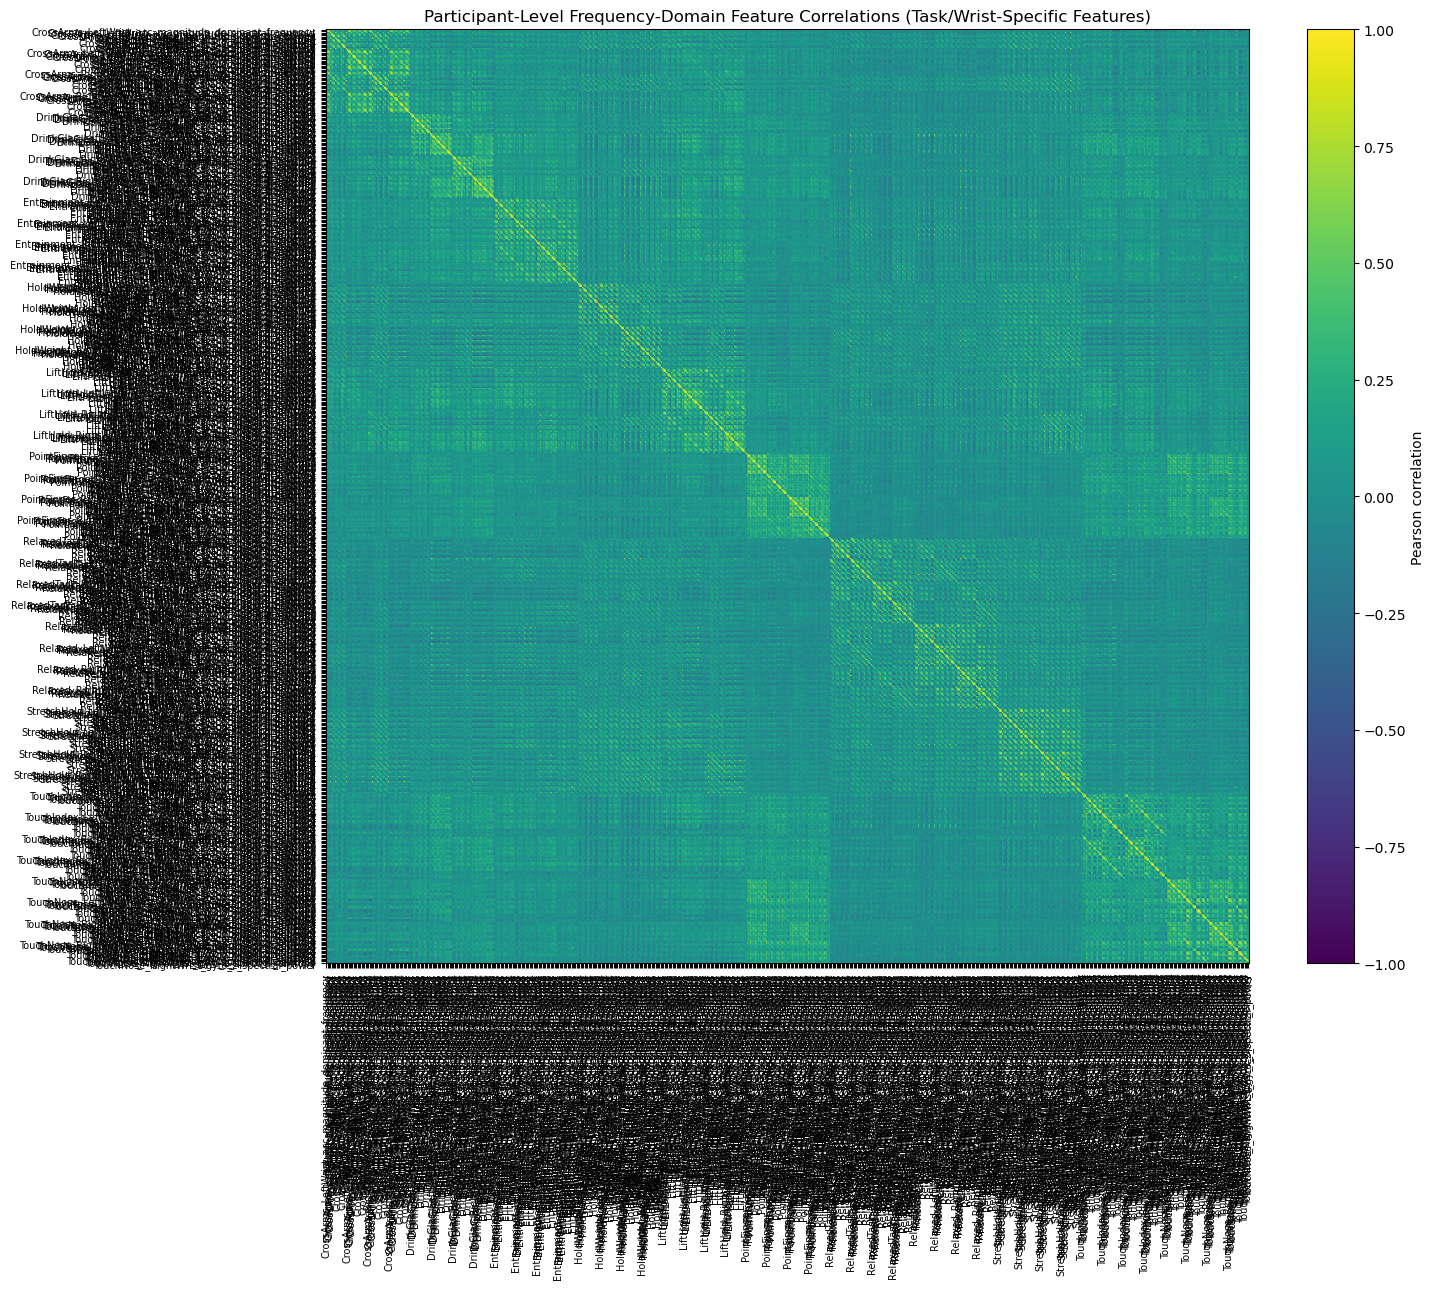

In [15]:
figure, axis = plt.subplots(figsize=(15, 13))

image = axis.imshow(
    correlation_matrix.to_numpy(),
    aspect="auto",
    vmin=-1,
    vmax=1,
)

axis.set_xticks(range(len(correlation_matrix.columns)))
axis.set_xticklabels(
    correlation_matrix.columns,
    rotation=90,
    fontsize=7,
)

axis.set_yticks(range(len(correlation_matrix.index)))
axis.set_yticklabels(
    correlation_matrix.index,
    fontsize=7,
)

axis.set_title(
    "Participant-Level Frequency-Domain Feature Correlations "
    "(Task/Wrist-Specific Features)"
)

figure.colorbar(
    image,
    ax=axis,
    label="Pearson correlation",
)

figure.tight_layout()
plt.show()


## 11. Strongly Correlated Wearable Features

In [16]:
# Identify unique strongly correlated feature pairs.
upper_triangle_mask = np.triu(
    np.ones(
        correlation_matrix.shape,
        dtype=bool,
    ),
    k=1,
)

upper_triangle = correlation_matrix.where(
    upper_triangle_mask
)

strong_pairs = []

for feature_1 in upper_triangle.columns:
    for feature_2, correlation in (
        upper_triangle[feature_1]
        .dropna()
        .items()
    ):
        if abs(correlation) >= STRONG_CORRELATION_THRESHOLD:
            strong_pairs.append(
                {
                    "feature_1": feature_2,
                    "feature_2": feature_1,
                    "correlation": correlation,
                    "absolute_correlation": abs(correlation),
                    "direction": (
                        "positive"
                        if correlation >= 0
                        else "negative"
                    ),
                    "relationship_group": (
                        "participant_level_frequency_features"
                    ),
                }
            )

strong_correlations = pd.DataFrame(
    strong_pairs
)

if not strong_correlations.empty:
    strong_correlations = (
        strong_correlations
        .sort_values(
            "absolute_correlation",
            ascending=False,
        )
        .reset_index(drop=True)
    )

print(
    "Strongly correlated pairs:",
    len(strong_correlations),
)

strong_correlations.head(30)

Strongly correlated pairs: 272


,feature_1,feature_2,correlation,absolute_correlation,direction,relationship_group
0,Relaxed_LeftWrist_acc_magnitude_spectral_power,Relaxed_LeftWrist_acc_z_spectral_power,0.986866,0.986866,positive,participant_level_frequency_features
1,CrossArms_LeftWrist_acc_x_spectral_power,CrossArms_LeftWrist_acc_z_spectral_power,0.982043,0.982043,positive,participant_level_frequency_features
2,CrossArms_RightWrist_acc_magnitude_spectral_power,CrossArms_RightWrist_acc_x_spectral_power,0.981660,0.981660,positive,participant_level_frequency_features
3,Relaxed_LeftWrist_acc_magnitude_spectral_power,Relaxed_LeftWrist_acc_y_spectral_power,0.973444,0.973444,positive,participant_level_frequency_features
4,CrossArms_LeftWrist_acc_z_spectral_power,CrossArms_RightWrist_acc_x_spectral_power,0.972662,0.972662,positive,participant_level_frequency_features
5,StretchHold_RightWrist_acc_x_spectral_power,StretchHold_RightWrist_gyro_z_spectral_power,0.967805,0.967805,positive,participant_level_frequency_features
6,CrossArms_RightWrist_acc_magnitude_spectral_power,CrossArms_RightWrist_acc_z_spectral_power,0.966170,0.966170,positive,participant_level_frequency_features
7,RelaxedTask_LeftWrist_gyro_magnitude_spectral_...,RelaxedTask_LeftWrist_gyro_x_spectral_power,0.963597,0.963597,positive,participant_level_frequency_features
8,PointFinger_LeftWrist_acc_magnitude_spectral_p...,PointFinger_LeftWrist_acc_z_spectral_power,0.963129,0.963129,positive,participant_level_frequency_features
9,Relaxed_LeftWrist_acc_y_spectral_power,Relaxed_LeftWrist_acc_z_spectral_power,0.960948,0.960948,positive,participant_level_frequency_features


In [17]:
if strong_correlations.empty:
    strong_correlation_group_summary = pd.DataFrame(
        columns=[
            "relationship_group",
            "direction",
            "feature_pairs",
        ]
    )
else:
    strong_correlation_group_summary = (
        strong_correlations
        .groupby(
            ["relationship_group", "direction"],
            as_index=False,
        )
        .size()
        .rename(columns={"size": "feature_pairs"})
    )

strong_correlation_group_summary


,relationship_group,direction,feature_pairs
0,participant_level_frequency_features,positive,272


## 12. Save Correlation and Resampling Outputs

In [18]:
correlation_summary = pd.DataFrame(
    {
        "metric": [
            "Participants",
            "Participant-level frequency features",
            "Strong correlation threshold",
            "Strongly correlated feature pairs",
            "Target sampling frequency (Hz)",
            "Recordings analyzed",
            "Recordings with preserved post-trim length",
            "Observed post-trim lengths",
        ],
        "value": [
            int(
                frequency_features_wide[
                    "patient_id"
                ].nunique()
            ),
            len(participant_frequency_columns),
            STRONG_CORRELATION_THRESHOLD,
            len(strong_correlations),
            TARGET_SAMPLING_FREQUENCY,
            len(frequency_features),
            int(lengths_preserved.sum()),
            ", ".join(
                str(value)
                for value in sorted(observed_lengths)
            ),
        ],
    }
)

CORRELATION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

correlation_matrix.to_csv(
    CORRELATION_MATRIX_OUTPUT
)

strong_correlations.to_csv(
    STRONG_CORRELATIONS_OUTPUT,
    index=False,
)

correlation_summary.to_csv(
    CORRELATION_SUMMARY_OUTPUT,
    index=False,
)

post_resampling_length_summary.to_csv(
    RESAMPLING_LENGTH_OUTPUT,
    index=False,
)

output_paths = [
    CORRELATION_MATRIX_OUTPUT,
    STRONG_CORRELATIONS_OUTPUT,
    CORRELATION_SUMMARY_OUTPUT,
    RESAMPLING_LENGTH_OUTPUT,
]

for output_path in output_paths:
    if (
        not output_path.exists()
        or output_path.stat().st_size == 0
    ):
        raise IOError(
            f"Output was not saved correctly: "
            f"{output_path}"
        )

    print("Saved:", output_path)

correlation_summary

Saved: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\correlation_analysis\frequency_feature_correlation_matrix.csv
Saved: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\correlation_analysis\strongly_correlated_features.csv
Saved: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\correlation_analysis\correlation_analysis_summary.csv
Saved: c:\Users\bramw\OneDrive - GUSCanada\Desktop\Semester 5\Capstone Project\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\correlation_analysis\post_resampling_length_summary.csv


,metric,value
0,Participants,469
1,Participant-level frequency features,704
2,Strong correlation threshold,0.8
3,Strongly correlated feature pairs,272
4,Target sampling frequency (Hz),100.0
5,Recordings analyzed,10318
6,Recordings with preserved post-trim length,10318
7,Observed post-trim lengths,"976, 2000"


## 13. Final Summary

Upon successful execution, this notebook confirms that:

- all 469 participant files are processed;
- 10,318 recordings are analyzed;
- every recording is interpolated onto a uniform 100 Hz grid before FFT-based feature extraction;
- the original timestamp-based sampling frequency is retained only for QA;
- the post-trim lengths of 976 and 2,000 samples are preserved;
- 32 frequency-domain features are extracted per recording;
- the recording-level features are reshaped into a **participant-level wide table with exactly one row per patient**;
- each task/wrist/feature combination becomes its own column;
- `frequency_domain_features.csv` stores the one-row-per-patient table for downstream use;
- the original recording-level table is retained separately for QA;
- correlations are calculated across the participant-level task/wrist-specific features; and
- strongly correlated feature pairs are identified using `|r| ≥ 0.80`.
